# <span style="color:red"> Modelling partial differential equations
    
### <span style="color:blue"> Notebook created by Abolfazl Irani Rahaghi - abolfazl.irani@eawag.ch

#### <span style="color:green"> BMSLO 2026 [CC-BY-NC-SA 4.0]

<div style="padding:8px 0 8px 15px;border-left:3px solid #B51F1F;background-color:#F3F3F3;">
    <span style="text-decoration:underline;font-weight:bold;">How to follow the session?</span><br/>
    Use the "Numerical_methods_Part_II.ipynb" during the course. You can find the solutions later in "Numerical_methods_Part_II_solutions.ipynb".
    
<div style="background-color:#F3F3F3;">
    <span style="text-decoration:underline;font-weight:bold;">How to use this notebook?</span><br/>
    This notebook is made of text cells and code cells. The code cells have to be <strong>executed</strong> to see the result of the program.<br/>To execute a cell, simply select it and click on the "play" button (<span style="font: bold 12px/30px Arial, serif;">&#9658;</span>) in the tool bar just above the notebook, or type <code>shift + enter</code>. <br/>It is important to execute the code cells in their order of appearance in the notebook.
</div>

## <span style="color:blue">Example 1: Implementing forward method in Python (Step 5)

In [1]:
### import Python packages needed for this course 

import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.animation import FuncAnimation, PillowWriter  

import numpy as np
import scipy
from scipy import sparse

In [2]:
def I(x,xL):  # xL is maximum depth (xL=H) 
    """Profile of initial condition."""
    if x < xL/2:
        return 0
    else:
        return 4


In [3]:
def grid(x0,xL,dx,t0, tf, dt): 
    M=(xL-x0)/dx+1     # ----- Spatial discretization step -----
    M=np.floor(M)
    M=int(M)
    dx=(xL-x0)/(M-1) #  adjust dx if needed
    
    N=(tf - t0)/dt +1     # ----- Time step -----
    N=np.floor(N)
    N=int(N)
    tf=(N-1)*dt+t0  # adjust tf if needed

    xspan = np.linspace(x0, xL, M)     # ----- Creates grids -----
    tspan = np.linspace(t0, tf, N)
    
    return M,N,dx,xspan,tspan

## Exercise 1

In [4]:
def diffu_explicit_dirichlet(D,x0,xL,dx,t0, tf, dt, T0, T1, I):
    """ solve the heat equation using an explicit method (forward Euler) with Dirichlet BC"""
        
    M,N,dx,xspan,tspan = grid(x0,xL,dx,t0, tf, dt)

    F = dt*D/dx**2 # ----- non dimensional number -----
        
    U = np.zeros((M, N)) # ----- Initializes matrix U -----

    for i in range(0, M):  # ----- Initial condition ----- Set initial condition u(x,0) = I(x)
        U[i,0] = I(xspan[i],xL)
        
    U[0,:] = T0  # ----- Dirichlet Boundary Conditions -----
    U[-1,:] = T1

    for k in range(0, N-1):     # ----- Equation -----
        for i in range(1, M-1):
            U[i, k+1] = F*U[i-1, k] + (1-2*F)*U[i,k] + F*U[i+1,k] 

    T, X = np.meshgrid(tspan, xspan) # will be used for 2D plotting
    
    return U, T, X, F, xspan, tspan



In [5]:
#run model
U, T, X, F, xspan, tspan= diffu_explicit_dirichlet(D=1e-6,x0=0,xL=10,dx=0.1,t0=0, tf=30*86400, dt=3600, T0=0, T1=4, I=I)

print('F = %5.2f.' % F)

# visualisation of the model
t1 = 5*86400 # select time 
index1 = np.argmin(np.abs(np.array(T)-t1))

F =  0.36.


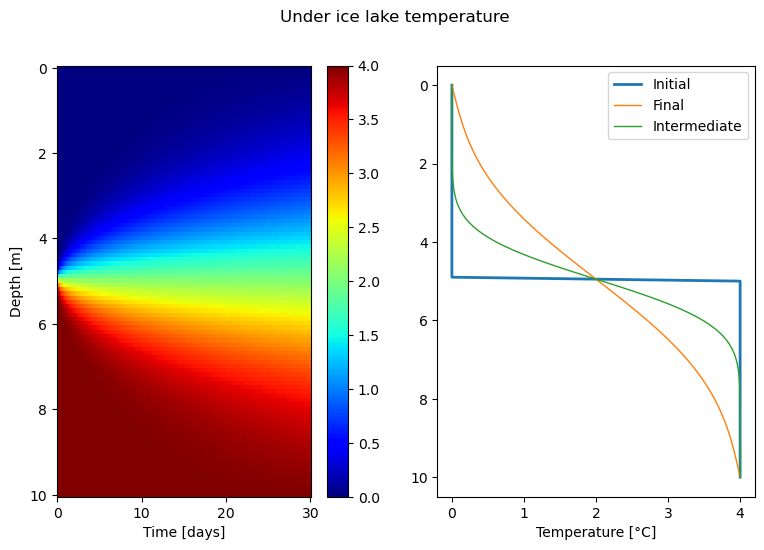

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 5.6))
fig.suptitle('Under ice lake temperature')
cc=ax1.pcolor(T/86400, X, U, cmap='jet')
fig.colorbar(cc, ax=ax1)
ax2.plot(U[:,0],X[:,0], linewidth=2, label = 'Initial')
l1 = plt.plot(U[:,-1],X[:,0], linewidth=1, label = 'Final')
l1 = plt.plot(U[:,index1],X[:,0], linewidth=1, label = 'Intermediate')
ax2.set(xlabel= 'Temperature [°C]')
ax1.set(xlabel= 'Time [days]')
ax1.set(ylabel= 'Depth [m]')
ax1.invert_yaxis()
ax2.invert_yaxis()
ax2.legend(loc="upper right")
plt.show()

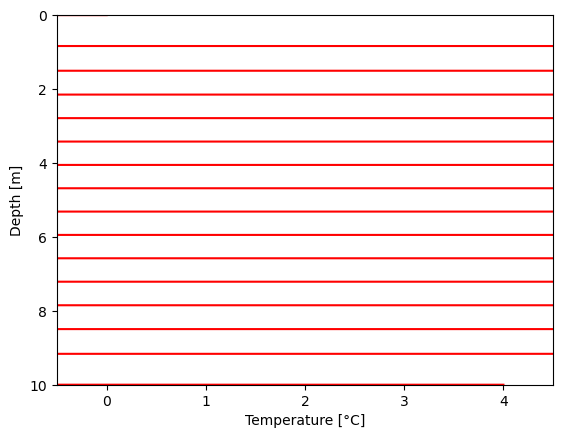

In [13]:
# create animation

def init():  
    ax.set_xlim(-0.5, 4.5)  
    ax.set_ylim(0, 10) 
    ax.invert_yaxis()
  
def update(i):  
    y = U[:,i] 
    ln1.set_data(y,x)

fig, ax = plt.subplots()  
x,y =  [], [],   
ln1, = plt.plot([],[], 'r')  
ax.set(xlabel= 'Temperature [°C]')
ax.set(ylabel= 'Depth [m]')
x = xspan
ax.invert_yaxis()

ani = FuncAnimation(fig, update, frames=np.arange(0, len(tspan)), init_func=init)
# https://matplotlib.org/stable/api/_as_gen/matplotlib.animation.FuncAnimation.html

writer = PillowWriter(fps=25)
# https://matplotlib.org/stable/api/_as_gen/matplotlib.animation.PillowWriter.html
ani.save("diffusion.gif", writer=writer)

## Exercise 2: Testing the code in Python (Step 6)

In [10]:
#run model
U, T, X, F, xspan, tspan= diffu_explicit_dirichlet(D=1.1e-4,x0=0,xL=10,dx=0.6,t0=0, tf=30*86400, dt=3600*0.5, T0=0, T1=4, I=I)

print('F = %5.2f.' % F)

# visualisation of the model
t1 = 3*86400/4 # select time 
index1 = np.argmin(np.abs(np.array(T)-t1))


F =  0.51.


/var/folders/97/q3x5b49d0kxbg8xzqjkytv1h0000gs/T/ipykernel_60214/481174289.py:4: UserWarning: Adding colorbar to a different Figure <Figure size 900x560 with 3 Axes> than <Figure size 1000x600 with 3 Axes> which fig.colorbar is called on.
  fig.colorbar(cc, ax=ax1)


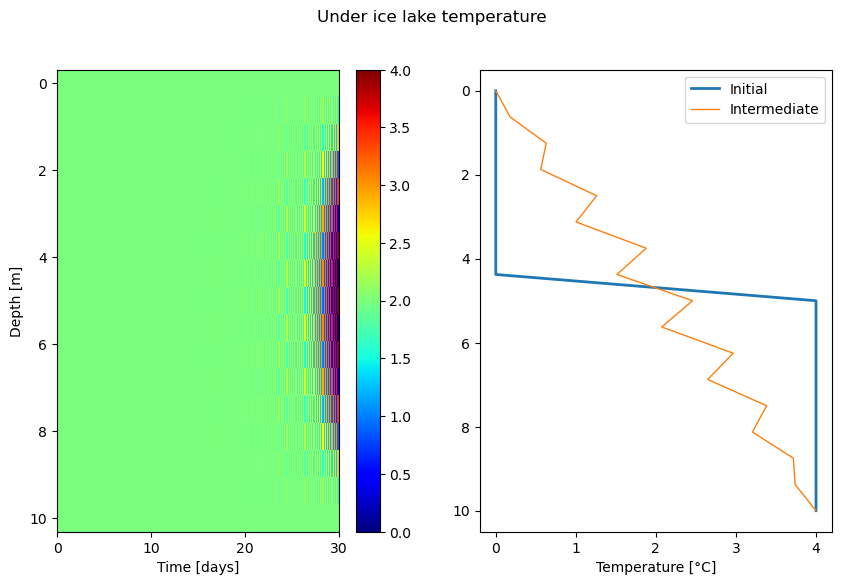

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))
fig.suptitle('Under ice lake temperature')
ax1.pcolor(T/86400, X, U, cmap='jet')
fig.colorbar(cc, ax=ax1)
ax2.plot(U[:,0],X[:,0], linewidth=2, label = 'Initial')
# l1 = plt.plot(U[:,-1],X[:,0], linewidth=1, label = 'Final')
l1 = plt.plot(U[:,index1],X[:,0], linewidth=1, label = 'Intermediate')
ax2.set(xlabel= 'Temperature [°C]')
ax1.set(xlabel= 'Time [days]')
ax1.set(ylabel= 'Depth [m]')
ax1.invert_yaxis()
ax2.invert_yaxis()
ax2.legend(loc="upper right")
plt.show()

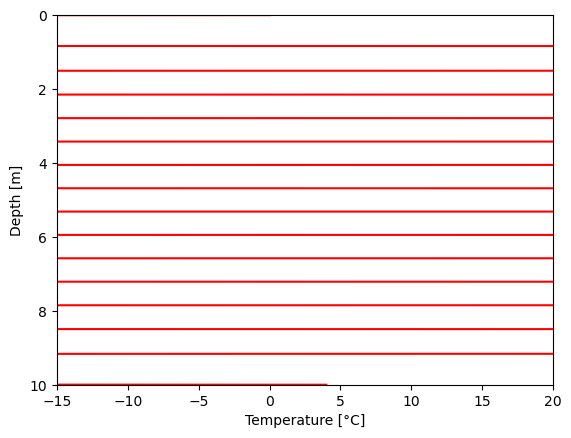

In [12]:
# create animation
fig, ax = plt.subplots()  
x,y =  [], [],   
ln1, = plt.plot([],[], 'r')  
ax.invert_yaxis()
ax.set(xlabel= 'Temperature [°C]')
ax.set(ylabel= 'Depth [m]')
x = xspan

def init():  
    ax.set_xlim(-15, 20)  
    ax.set_ylim(0, 10)
    ax.invert_yaxis()
  
def update(i):  
    y = U[:,i] 
    ln1.set_data(y,x)  

ani = FuncAnimation(fig, update, frames=np.arange(0, len(tspan)), init_func=init)  

writer = PillowWriter(fps=10)  
ani.save("diffusion_unstable.gif", writer=writer)

## <span style="color:blue">Example 2: Implementing backward method in Python

In [11]:
def diffu_implicit_dirichlet(D,x0,xL,dx,t0, tf, dt, T0, T1, I):
    '''    Backward method to solve 1D diffusion equation:    u_t = D * u_xx 
    with Dirichlet boundary conditions u(x0,t) = 0, u(xL,t) = 4
    and initial condition u(x,0) = I(x)    '''
    
    M,N,dx,xspan,tspan = grid(x0,xL,dx,t0, tf, dt)

    F = dt*D/dx**2

    main_diag = (1 + 2*F)*np.ones((1,M-2)) # ----- Create matrix A -----
    off_diag = -F*np.ones((1, M-3))
    a = main_diag.shape[1]
    diagonals = [main_diag, off_diag, off_diag]
    A = sparse.diags(diagonals, [0,-1,1], shape=(a,a)).toarray()
    # https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.diags.html
    
    U = np.zeros((M, N))     # ----- Initializes matrix U -----

    for i in range(0, M):    # Set initial condition u(x,0) = I(x)
        U[i,0] = I(xspan[i],xL)

    U[0,:] = T0 # ----- Dirichlet Boundary Conditions -----
    U[-1,:] = T1

    for k in range(1, N): # ----- Solving matrix equation -----
        c = np.zeros((M-4,1)).ravel() # numpy.ravel returns a contiguous flattened array
        b1 = np.asarray([F*U[0,k], F*U[-1,k]])
        b1 = np.insert(b1, 1, c) # b1 represents the green B matrix in the course
        b2 = np.array(U[1:M-1, k-1]) # b2 represents the blue U^n matrix in the course
        b = b1 + b2  # Right hand side
        U[1:M-1, k] = np.linalg.solve(A,b)  # Solve Ax=b
        
    T, X = np.meshgrid(tspan, xspan)
        
    return U, T, X, F, xspan, tspan


In [12]:

U1, T1, X1, F1, xspan1, tspan1= diffu_explicit_dirichlet(D=1e-5,x0=0,xL=10,dx=0.26,t0=0, tf=30*86400, dt=3600, T0=0, T1=4, I=I)
U2, T2, X2, F2, xspan2, tspan2= diffu_implicit_dirichlet(D=1e-5,x0=0,xL=10,dx=0.26,t0=0, tf=30*86400, dt=3600, T0=0, T1=4, I=I)

print('F = %5.2f.' % F2)

# visualisation of the model
t1 = 3*8640/4 # select time 
index1 = np.argmin(np.abs(np.array(T1)-t1))


F =  0.52.


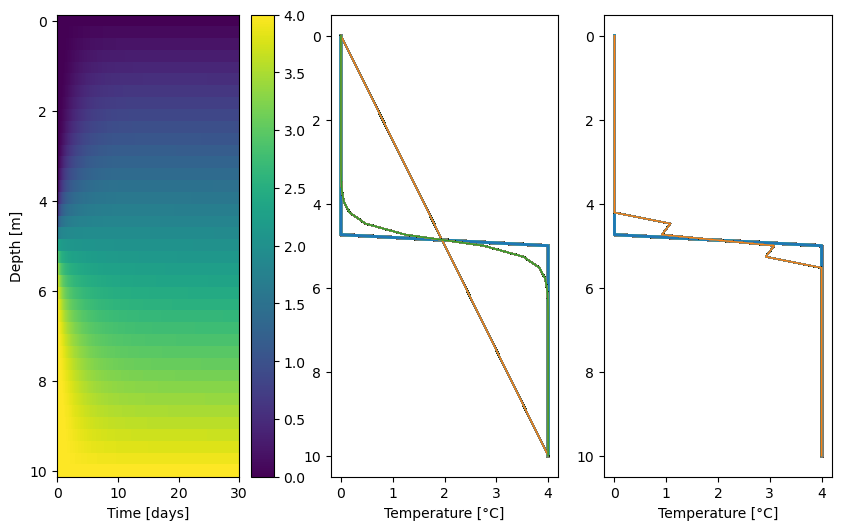

In [13]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 6))
cc=ax1.pcolor(T2/86400, X2, U2, cmap='viridis',shading='auto')
fig.colorbar(cc, ax=ax1)
ax2.plot(U2[:,0],X2, linewidth=2)
ax2.plot(U2[:,-1],X2, linewidth=1)
ax2.plot(U2[:,index1],X2, linewidth=1)
ax3.plot(U1[:,0],X1, linewidth=2)
ax3.plot(U1[:,index1],X1, linewidth=1)
ax3.set(xlabel= 'Temperature [°C]')
ax2.set(xlabel= 'Temperature [°C]')
ax1.set(xlabel= 'Time [days]')
ax1.set(ylabel= 'Depth [m]')
ax1.invert_yaxis()
ax2.invert_yaxis()
ax3.invert_yaxis()
plt.show()

## <span style="color:blue">Example 3: Implementing backward method code with Neumann boundary condition

In [14]:
def I2(x,xL):
    """Profile of initial condition."""
    if x < xL/2:
        return 0
    else:
        return 2
    

In [15]:
def diffu_implicit_neumann_dirichlet(D,x0,xL,dx,t0, tf, dt, T0, L, I):
    '''Backward method to solve 1D diffusion equation    
    with Dirichlet and Neumann boundary conditions 
    and initial condition '''
    
    M,N,dx,xspan,tspan = grid(x0,xL,dx,t0, tf, dt)

    F = dt*D/dx**2
    
    main_diag = (1 + 2*F)*np.ones((1,M-1))
    off_diag = -F*np.ones((1, M-2))
    a = main_diag.shape[1]
    diagonals = [main_diag, off_diag, off_diag]
    A = sparse.diags(diagonals, [0,-1,1], shape=(a,a)).toarray()
    A[0,1] = -F
    A[M-2,M-3] = -2*F

    U = np.zeros((M, N))

    for i in range(0, M): # Set initial condition u(x,0) = I(x)
        U[i,0] = I(xspan[i],xL)
        
    
    U[0,:] = T0 #----- Dirichlet boundary conditions -----
    NeuBC=L*np.ones(N) #----- Neumann boundary conditions -----
        
    for k in range(1, N):
        c = np.zeros((M-3,1)).ravel()
        b1 = np.asarray([-F*U[0,k], 2*F*dx*NeuBC[k]])
        b1 = np.insert(b1, 1, c)
        b2 = np.array(U[1:M, k-1])
        b = b1 + b2  # Right hand side
        U[1:M, k] = np.linalg.solve(A,b)  # Solve Ax=b

    
    return U, tspan, xspan, F



In [16]:
U, tspan, xspan, F= diffu_implicit_neumann_dirichlet(D=1e-6,x0=0,xL=10,dx=0.25,t0=0, tf=86400*30, dt=3600, T0=0, L=0.1, I=I2)


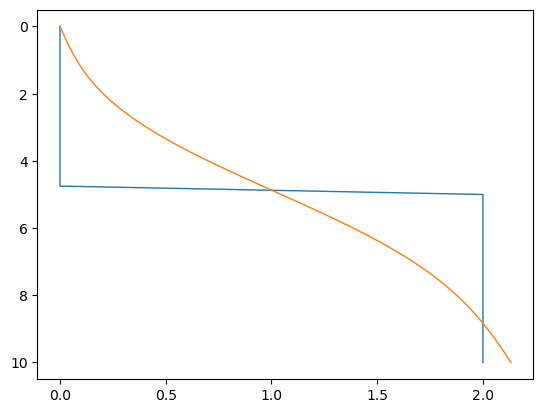

In [17]:
fig = plt.figure()
plt.plot(U[:,0],xspan, linewidth=1)
plt.plot(U[:,-1],xspan, linewidth=1)
plt.gca().invert_yaxis()
plt.show()


## <span style="color:blue">Example 4:  Implementing and testing FTCS code in python

In [18]:
def I(x): # initial condition
    return  np.exp(-200*(x-0.25)**2)


In [19]:
def solver_adv_FTCS(v,x0,xL,dx,t0, tf, dt, I):
    '''    FTCS method to solve 1D advection equation:    u_t = -v * u_x 
    with periodic boundary conditions and initial condition u(x,0) = I(x)    '''
    
    M,N,dx,xspan,tspan = grid(x0,xL,dx,t0, tf, dt)

    C = v*dt/dx # nondimensional

    U = np.zeros((M, N))     # ----- Initializes matrix solution U -----

    # ----- Initial condition -----
    # Set initial condition u(x,0) = I(x)
    for i in range(0, M):
        U[i,0] = I(xspan[i])

    # ----- Equation -----
    for n in range(0, N-1):
        for i in range(1, M-1):
            U[i, n+1] = U[i, n] - 0.5 * C * (U[i+1,n] - U[i-1,n])
        # ----- Periodic Boundary Conditions -----
        U[0,n+1] = U[0,n]-0.5 * C * (U[1,n] - U[M-1,n])  
        U[M-1,n+1] = U[M-1,n]-0.5 * C * (U[1,n] - U[M-2,n])
        # # ----- Periodic Boundary Conditions: a simpler approach -----
        # U[0,n+1] = U[M-2,n+1]   
        # U[M-1,n+1] = U[1,n+1]

    return xspan, tspan, U, C


### <span style="color:blue">Step 6: Testing the code


In [20]:
xspan, tspan, U, C = solver_adv_FTCS(v=1, x0=0, xL= 3, dx= 0.01, t0=0, tf=2.75, dt=0.001, I=I)

print(C)


0.1


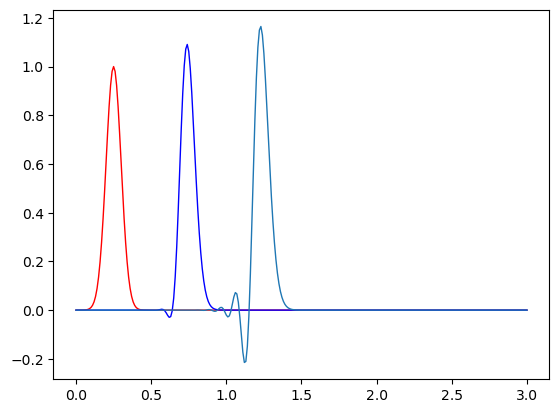

In [21]:
t1 = 0.5
index1 = np.argmin(np.abs(np.array(tspan)-t1))
t1 = 1
index2 = np.argmin(np.abs(np.array(tspan)-t1))

fig = plt.figure()
l1 = plt.plot(xspan,U[:,0],'-r', linewidth=1)
l2 = plt.plot(xspan,U[:,index1],'-b', linewidth=1)
l3 = plt.plot(xspan,U[:,index2], linewidth=1)


plt.show()

## ex: stabilize the code by changing dt and or dx


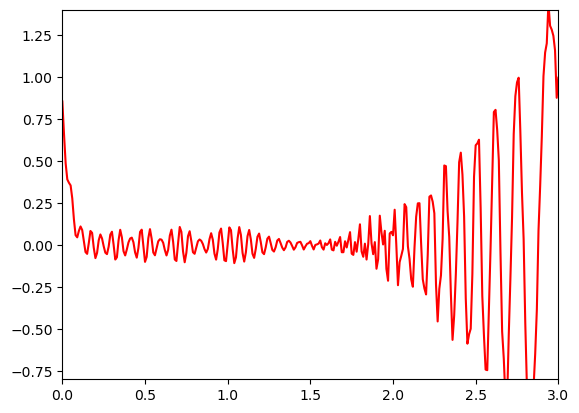

In [22]:
fig, ax = plt.subplots()  
x, y = [], [],   
ln1, = plt.plot([], [], 'r')  

def init():  
    ax.set_xlim(0, 3)  
    ax.set_ylim(-0.8, 1.4)  
  
def update(i):   
    ln1.set_data(xspan, U[:,i])  

ani = FuncAnimation(fig, update, frames=np.arange(0, len(tspan),10), init_func=init)  

writer = PillowWriter(fps=50)  
ani.save("adv_FCTS.gif", writer=writer) 


## <span style="color:blue">Example 5:  Implementing and testing Lax-Friedrichs method in python

In [23]:
def solver_adv_Lax_Friedrichs(v,x0,xL,dx,t0, tf, dt,I):

    M,N,dx,xspan,tspan = grid(x0,xL,dx,t0, tf, dt)

    C = v*dt/dx
    
    xspan = np.linspace(x0, xL, M) # ----- Creates grids -----
    tspan = np.linspace(t0, tf, N)

    U = np.zeros((M, N))     # ----- Initializes matrix solution U -----

    for i in range(0, M):     # Set initial condition u(x,0) = I(x)
        U[i,0] = I(xspan[i])

    for n in range(0, N-1):     # ----- Equation -----
        for i in range(1, M-1):
            U[i, n+1] = 0.5* (U[i+1,n]+U[i-1,n]) - 0.5 *C*(U[i+1,n]-U[i-1,n])
        # ----- Periodic Boundary Conditions -----
        U[0,n+1] = U[0,n]-0.5 * C * (U[1,n] - U[M-1,n])  
        U[M-1,n+1] = U[M-1,n]-0.5 * C * (U[1,n] - U[M-2,n])
        # # ----- Periodic Boundary Conditions: a simpler approach -----
        # U[0,n+1] = U[M-2,n+1]   
        # U[M-1,n+1] = U[1,n+1]

    return xspan, tspan, U, C


In [24]:
xspan2, tspan2, U2, C2 = solver_adv_Lax_Friedrichs(v=1, x0=0, xL= 3, dx= 0.01, t0=0, tf=10.75, dt=0.005, I=I)
print('CFL = ', C2)


CFL =  0.5


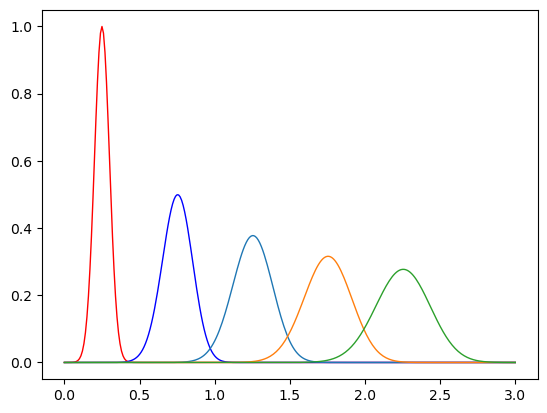

In [25]:
t1 = 0.5
index1 = np.argmin(np.abs(np.array(tspan2)-t1))
t1 = 1
index2 = np.argmin(np.abs(np.array(tspan2)-t1))
t1 = 1.5
index3 = np.argmin(np.abs(np.array(tspan2)-t1))
t1 = 2
index4 = np.argmin(np.abs(np.array(tspan2)-t1))

fig = plt.figure()
l1 = plt.plot(xspan2,U2[:,0],'-r', linewidth=1)
l2 = plt.plot(xspan2,U2[:,index1],'-b', linewidth=1)
l3 = plt.plot(xspan2,U2[:,index2], linewidth=1)
l4 = plt.plot(xspan2,U2[:,index3], linewidth=1)
l5 = plt.plot(xspan2,U2[:,index4], linewidth=1)

plt.show()


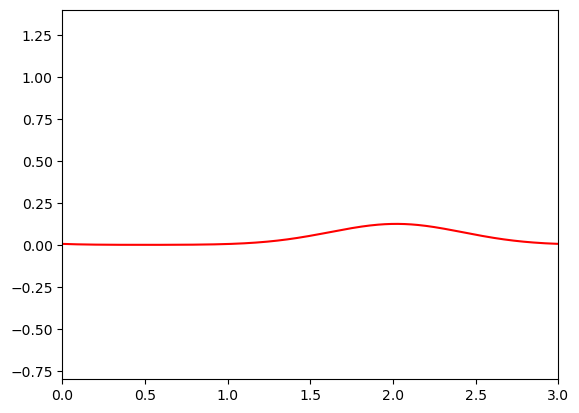

In [26]:
fig, ax = plt.subplots()  
x, y = [], [],   
ln1, = plt.plot([], [], 'r')  

def init():  
    ax.set_xlim(0, 3)  
    ax.set_ylim(-0.8, 1.4)  
  
def update(i):  
    ln1.set_data(xspan2, U2[:,i])  

ani = FuncAnimation(fig, update, frames=np.arange(0, len(tspan2),10), init_func=init)  

writer = PillowWriter(fps=25)  
ani.save("adv_lax_Friedriech.gif", writer=writer) 


## <span style="color:blue">Example 6:  Implementing and testing Lax-Wendroff method in python

In [27]:
def solver_adv_Lax_Wendroff(v,x0,xL,dx,t0, tf, dt,I):

    M,N,dx,xspan,tspan = grid(x0,xL,dx,t0, tf, dt)

    C = v*dt/dx
    
    xspan = np.linspace(x0, xL, M) # ----- Creates grids -----
    tspan = np.linspace(t0, tf, N)

    U = np.zeros((M, N))     # ----- Initializes matrix solution U -----

    for i in range(0, M):     # Set initial condition u(x,0) = I(x)
        U[i,0] = I(xspan[i])
        
    # ----- Equation -----
    for n in range(0, N-1):
        for i in range(1, M-1):
            U[i, n+1] = U[i, n] - 0.5* C *(U[i+1,n]-U[i-1,n]) + 0.5 *C**2*(U[i+1,n]-2*U[i,n]+U[i-1,n]) 
        # ----- Periodic Boundary Conditions -----
        U[0,n+1] = U[0,n]-0.5 * C * (U[1,n] - U[M-1,n])  
        U[M-1,n+1] = U[M-1,n]-0.5 * C * (U[1,n] - U[M-2,n])
        # # ----- Periodic Boundary Conditions: a simpler approach -----
        # U[0,n+1] = U[M-2,n+1]   
        # U[M-1,n+1] = U[1,n+1]

    return xspan, tspan, U, C


In [28]:
xspan3, tspan3, U3, C3 = solver_adv_Lax_Wendroff(v=1, x0=0, xL= 3, dx= 0.01, t0=0, tf=2.75, dt=0.005, I=I)
print('CFL = ', C3)


CFL =  0.5


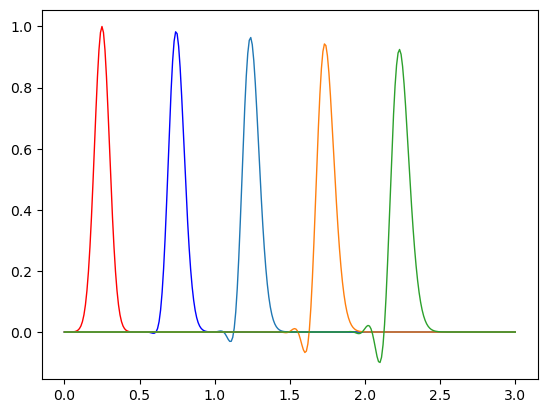

In [29]:
t1 = 0.5
index1 = np.argmin(np.abs(np.array(tspan3)-t1))
t1 = 1
index2 = np.argmin(np.abs(np.array(tspan3)-t1))
t1 = 1.5
index3 = np.argmin(np.abs(np.array(tspan3)-t1))
t1 = 2
index4 = np.argmin(np.abs(np.array(tspan3)-t1))

fig = plt.figure()
l1 = plt.plot(xspan3,U3[:,0],'-r', linewidth=1)
l2 = plt.plot(xspan3,U3[:,index1],'-b', linewidth=1)
l3 = plt.plot(xspan3,U3[:,index2], linewidth=1)
l4 = plt.plot(xspan3,U3[:,index3], linewidth=1)
l5 = plt.plot(xspan3,U3[:,index4], linewidth=1)

plt.show()


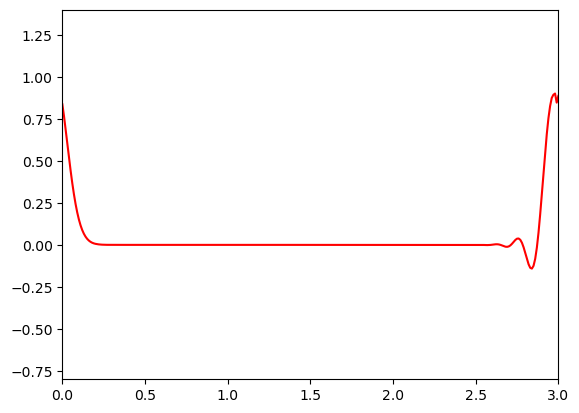

In [30]:
fig, ax = plt.subplots()  
x, y = [], [],   
ln1, = plt.plot([], [], 'r')  

def init():  
    ax.set_xlim(0, 3)  
    ax.set_ylim(-0.8, 1.4)  
  
def update(i):  
    ln1.set_data(xspan3, U3[:,i])  

ani = FuncAnimation(fig, update, frames=np.arange(0, len(tspan3),5), init_func=init)  

writer = PillowWriter(fps=25)  
ani.save("adv_lax_Wendroff.gif", writer=writer) 


In [31]:
xspan4, tspan4, U4, C4 = solver_adv_Lax_Wendroff(v=1.0, x0=0, xL= 3, dx= 0.01, t0=0, tf=2.75, dt=0.01, I=I)
print('CFL = ', C4)


CFL =  1.0


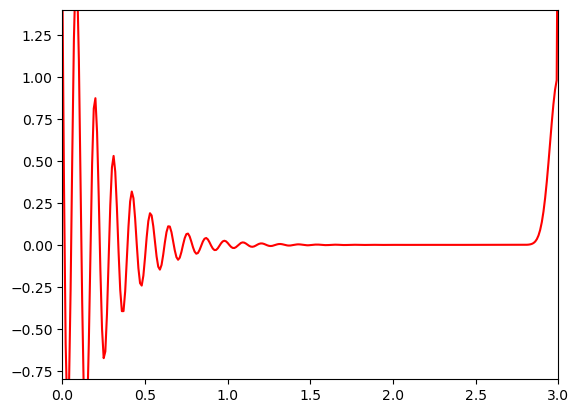

In [32]:
fig, ax = plt.subplots()  
x, y = [], [],   
ln1, = plt.plot([], [], 'r')  

def init():  
    ax.set_xlim(0, 3)  
    ax.set_ylim(-0.8, 1.4)  
  
def update(i):  
    ln1.set_data(xspan3, U4[:,i])  

ani = FuncAnimation(fig, update, frames=np.arange(0, len(tspan4),5), init_func=init)  

writer = PillowWriter(fps=25)  
ani.save("adv_lax_Wendroff2.gif", writer=writer) 
